In [1]:
# Importing the necessary libraries
import torch
from torch import optim, utils, tensor, nn

import matplotlib.pyplot as plt
from getdist import plots, MCSamples

from Network import Generator, Discriminator
from Signal_Generator import *

from tqdm import tqdm

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# Defining the hyperparameters
datasize = 16000
num_sources = 1
noise_amplitude = 0
freq_range = (1e-4, 1e-1)
total_time = 1000

num_latent_variables = 20
learning_rate = 1e-5
weight_clip = 0.1

d_loss_threshold = -0.1
g_loss_threshold = -0.3
threshold_adjustment = 0.025
max_steps = 300

num_epochs = 2000

In [3]:
# Defining the distribution for amplitude and angular frequency
def amp_distribution(size):
    """
    Amplitude distribution using uniform distribution.
    """
    return np.random.uniform(4, 16, size=size)

def omega_distribution(size):
    """
    Angular frequency distribution using uniform distribution.
    """
    return np.random.uniform(2 * np.pi * 1e-4, 2 * np.pi * 1e-1, size=size)

In [4]:
# Defining the WGAN traning class
class WGAN(nn.Module):
    def __init__(self, num_latent_variables, lr, weight_clip):
        super(WGAN, self).__init__()
        self.num_latent_variables = num_latent_variables
        self.lr = lr
        self.weight_clip = weight_clip

        # Networks
        self.generator = Generator(in_channels=1, num_latent_variables=num_latent_variables, length=len(signal), num_parameters=len(params)).to(device)
        self.discriminator = Discriminator(input_channels=1, length=len(signal), num_parameters=len(params)).to(device)

        # Optimizers
        self.optimizer_g = optim.Adam(self.generator.parameters(), lr=self.lr)
        self.optimizer_d = optim.Adam(self.discriminator.parameters(), lr=self.lr)

    def wasserstein_loss(self, output_d, y):
        return torch.mean(output_d * y)
    
    def train_generator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_g.zero_grad()
        g_loss.backward()
        self.optimizer_g.step()

        return g_loss.item(), d_loss.item()
    
    def train_discriminator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_d.zero_grad()
        d_loss.backward()
        self.optimizer_d.step()

        # Weight clipping
        for p in self.discriminator.parameters():
            p.data.clamp_(-self.weight_clip, self.weight_clip)

        return g_loss.item(), d_loss.item()

In [6]:
generator = torch.load('generator_2000sig.pt')
Discriminator = torch.load('discriminator_2000sig.pt')

generator.eval()

Generator(
  (init_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (init_relu): LeakyReLU(negative_slope=0.2)
  (res_block_no_norm): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (down1): Conditional_Down(
    (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): LeakyReLU(negative_slope=0.2)
    (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (res_block): Conditional_ResBlock(
      (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (leaky_relu): LeakyReLU(negative_slope=0.2)
      (process1): CIN(
        (inst_norm): InstanceNorm1d(

[10.09678660601651, 4.365890709944242, 6.174023108770631]
[array([10.093534,  4.303236,  6.361278], dtype=float32), array([9.950881 , 4.156763 , 5.8935804], dtype=float32), array([10.076154 ,  4.279568 ,  6.1493583], dtype=float32), array([9.930729 , 4.3279166, 6.088138 ], dtype=float32), array([10.080745 ,  4.2029285,  6.194783 ], dtype=float32), array([9.859513 , 4.2156167, 5.9937906], dtype=float32), array([9.742724, 4.168031, 6.221344], dtype=float32), array([10.024337 ,  4.283462 ,  6.0623636], dtype=float32), array([10.120859 ,  4.3065634,  6.154587 ], dtype=float32), array([10.003326,  4.270837,  6.166344], dtype=float32), array([9.997654 , 4.424252 , 6.2524834], dtype=float32), array([9.930468 , 4.3034163, 6.136661 ], dtype=float32), array([10.054707 ,  4.401241 ,  6.2020917], dtype=float32), array([10.024147 ,  4.1517577,  6.146374 ], dtype=float32), array([9.926545 , 4.3487687, 6.3588953], dtype=float32), array([9.995471, 4.225484, 5.850034], dtype=float32), array([9.979044, 

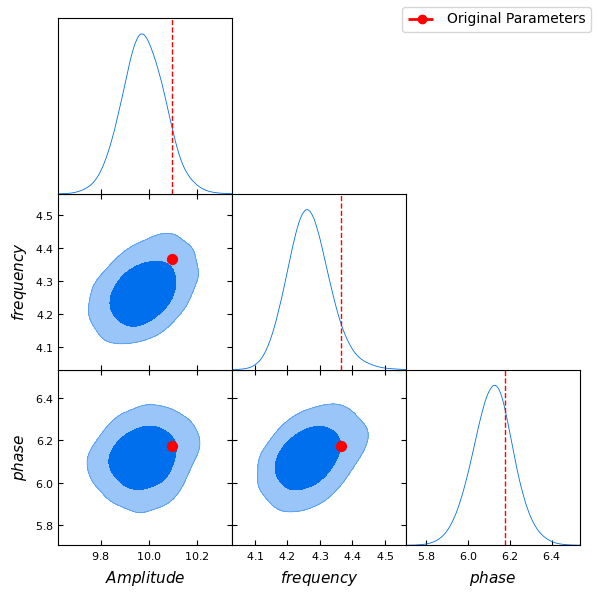

In [44]:
generated_params_list = []

TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time)
test_data = TS.generating_signal()
params = TS.printing_parameters()

input_signal = test_data['Signal'].values
input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

for i in range(10000):
    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    generated_params_list.append(generated_params)

print(params)
print(generated_params_list)

generated_params_df = pd.DataFrame(generated_params_list, columns=['Amplitude', 'Frequency', 'Phase'])

names = ["A","omega","theta"]
labels =  ["Amplitude","frequency","phase"]

generated_params_samples = MCSamples(samples=generated_params_df.values, names=names, labels=labels, settings={'ignore_rows': 1000})
generated_params_samples.updateSettings({'fine_bins_2D': 1048})

g = plots.get_subplot_plotter()

g.triangle_plot([generated_params_samples], filled=True)

axes = g.subplots

for i in range(len(names)):
    for j in range(i+1, len(names)):
        ax = axes[j, i]
        if ax is not None:
            ax.scatter(params[i], params[j], color='red', marker='o', s=50)

for i in range(len(names)):
    ax = axes[i, i]
    if ax is not None:
        ax.axvline(params[i], linestyle='--', color='red', lw=1)

handles = [plt.Line2D([0], [0], color='red', lw=2, linestyle='--', marker='o')]
labels = ['Original Parameters']
g.fig.legend(handles, labels, loc='upper right')

plt.show()

In [45]:
bias_mean = np.mean(generated_params_list - np.array(params), axis=0)
print(bias_mean)

[-0.11857836 -0.09921526 -0.05605774]


In [46]:
bias_var = np.var(generated_params_list - np.array(params), axis=0)
print(bias_var)

[0.00832418 0.00450228 0.01021932]


In [ ]:
""" for i in tqdm(range(50)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_generator(signal_tensor, params_tensor, z)
        loss_list.append(loss) """

In [ ]:
""" for i in tqdm(range(50)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_generator(signal_tensor, params_tensor, z)
        loss_list.append(loss) """

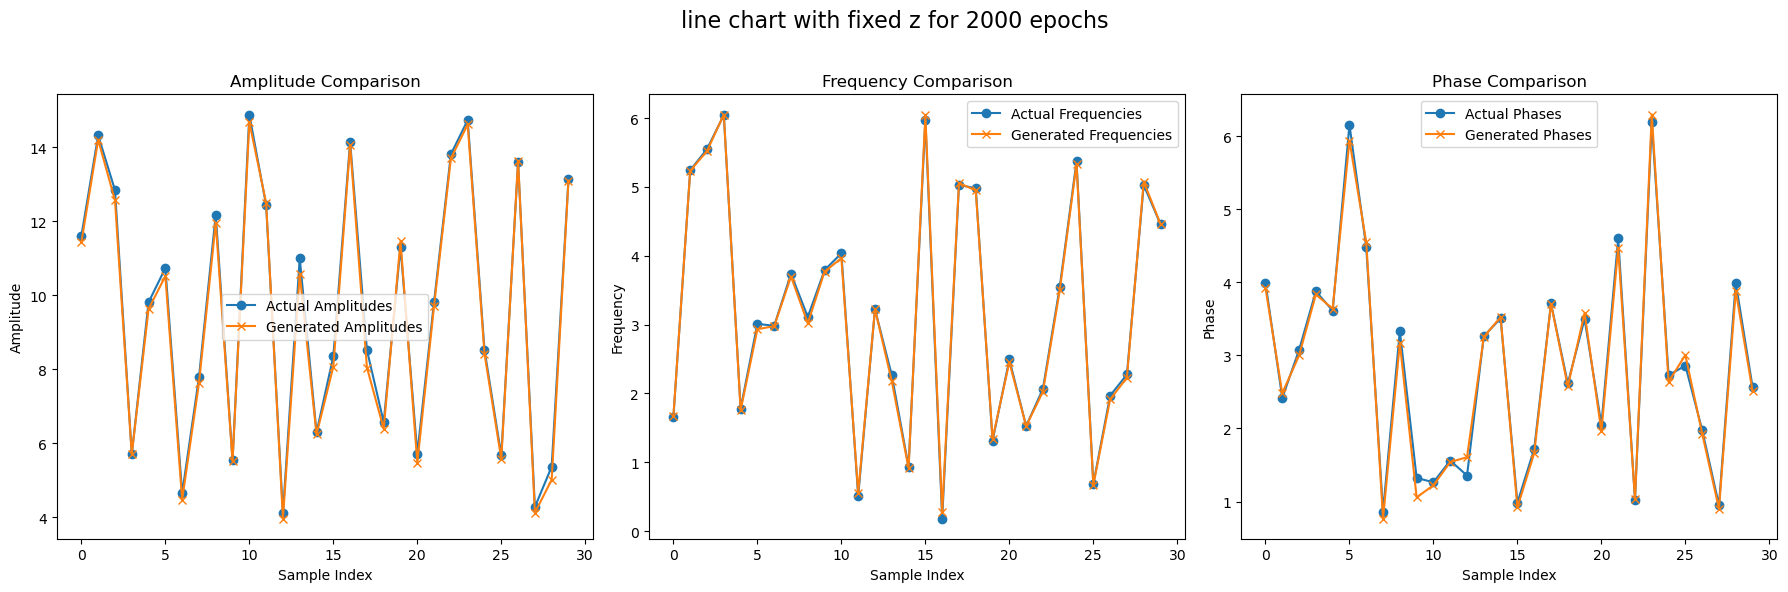

In [55]:
params_list = []
generated_params_list = []

test_times = 30
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, amp_distribution_func=amp_distribution
                          , omega_distribution_func=omega_distribution, freq_range=freq_range, total_time=total_time)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

    #print(params)
    #print(generated_params)

actual_amplitudes = [params[0] for params in params_list]
actual_frequencies = [params[1] for params in params_list]
actual_phases = [params[2] for params in params_list]

generated_amplitudes = [gen_params[0] for gen_params in generated_params_list]
generated_frequencies = [gen_params[1] for gen_params in generated_params_list]
generated_phases = [gen_params[2] for gen_params in generated_params_list]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(range(test_times), actual_amplitudes, 'o-', label='Actual Amplitudes')
plt.plot(range(test_times), generated_amplitudes, 'x-', label='Generated Amplitudes')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Amplitude Comparison')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(test_times), actual_frequencies, 'o-', label='Actual Frequencies')
plt.plot(range(test_times), generated_frequencies, 'x-', label='Generated Frequencies')
plt.xlabel('Sample Index')
plt.ylabel('Frequency')
plt.title('Frequency Comparison')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(test_times), actual_phases, 'o-', label='Actual Phases')
plt.plot(range(test_times), generated_phases, 'x-', label='Generated Phases')
plt.xlabel('Sample Index')
plt.ylabel('Phase')
plt.title('Phase Comparison')
plt.legend()

plt.suptitle(f'line chart with fixed z for {num_epochs} epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [56]:
bias = [generated - params for generated, params in zip(generated_params_list, params_list)]
print(bias)

[array([-0.17523661,  0.01259578, -0.06657698]), array([-0.12078132, -0.00620881,  0.06524375]), array([-0.27672467, -0.02851032, -0.07477949]), array([-0.00372093,  0.00683928, -0.0429805 ]), array([-0.18363381, -0.02546516,  0.02617797]), array([-0.21651232, -0.07794268, -0.21597488]), array([-0.17539859, -0.00550235,  0.06751015]), array([-0.1535958 , -0.03976814, -0.09522903]), array([-0.22138392, -0.09225241, -0.16700559]), array([-0.02647769, -0.02310047, -0.26602932]), array([-0.20997455, -0.06980196, -0.04073542]), array([ 0.0646194 ,  0.04463943, -0.02117706]), array([-0.13993946,  0.00459543,  0.2515474 ]), array([-0.42876139, -0.08882886, -0.01053736]), array([-0.05330094, -0.01931581,  0.01784091]), array([-0.27710196,  0.06656038, -0.06496143]), array([-0.09999924,  0.08813908, -0.05683973]), array([-0.47375287,  0.02629817, -0.00643307]), array([-0.17642019, -0.03213918, -0.04062711]), array([0.14736018, 0.03111543, 0.08167734]), array([-0.24993653, -0.03900813, -0.092918

In [57]:
bias_mean = np.mean(bias, axis=0)
print(bias_mean)

[-0.14998327 -0.01531058 -0.03266138]


In [58]:
bias_var = np.var(bias, axis=0)
print(bias_var)

[0.01739702 0.00186818 0.01040435]
